In [59]:
# 1. Data Preparation
import pandas as pd

# Load the dataset (Heart_disease sheet)
df = pd.read_excel('heart_disease.xlsx', sheet_name='Heart_disease')
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


In [60]:
# 2. Exploratory Data Analysis (EDA)
# Info & Missing Values
print(df.info())
print(df.isnull().sum())

# Summary statistics
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB
None
age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64


,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [61]:
# 3. Categorical Value Counts
cat_cols = ['sex','cp','fbs','restecg','exang','slope','thal']
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())


Value counts for sex:
sex
Male      718
Female    190
Name: count, dtype: int64
Value counts for cp:
cp
asymptomatic       495
non-anginal        203
atypical angina    165
typical angina      45
Name: count, dtype: int64
Value counts for fbs:
fbs
False    723
True     185
Name: count, dtype: int64
Value counts for restecg:
restecg
normal              542
lv hypertrophy      187
st-t abnormality    179
Name: count, dtype: int64
Value counts for exang:
exang
False    516
True     337
TURE      36
FALSE     19
Name: count, dtype: int64
Value counts for slope:
slope
flat           453
upsloping      298
downsloping    157
Name: count, dtype: int64
Value counts for thal:
thal
reversable defect    372
normal               339
fixed defect         197
Name: count, dtype: int64


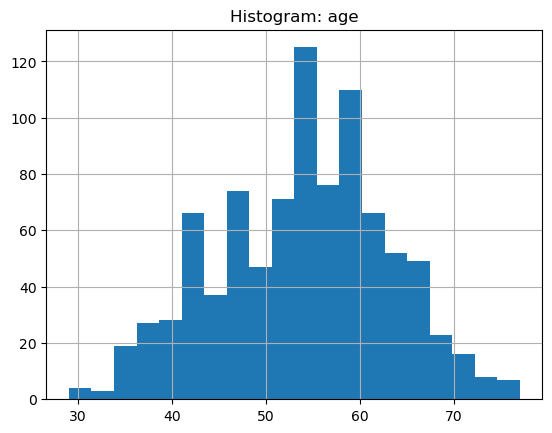

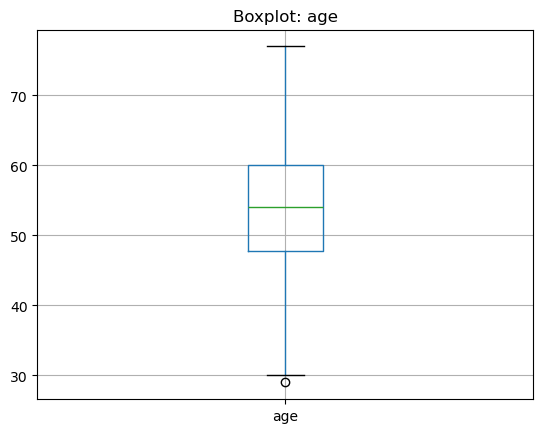

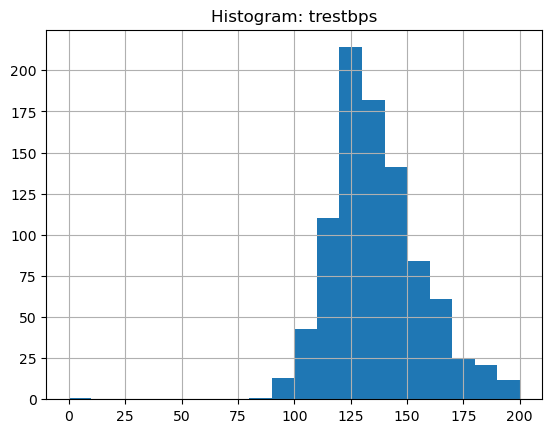

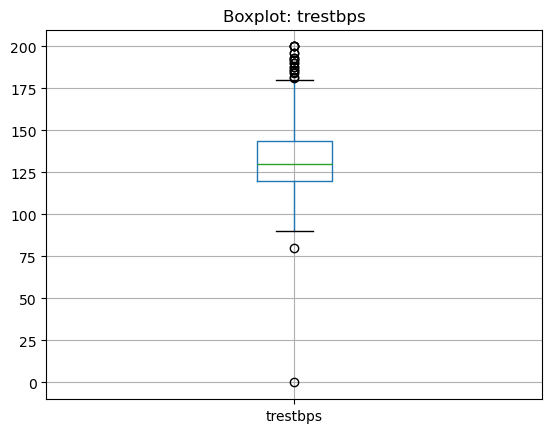

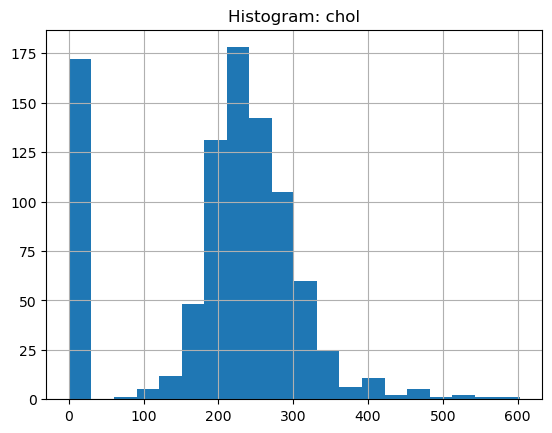

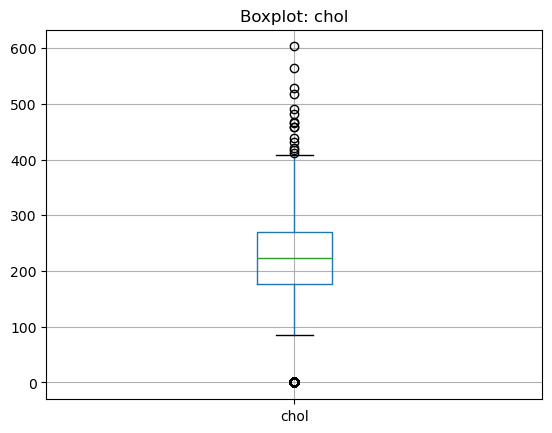

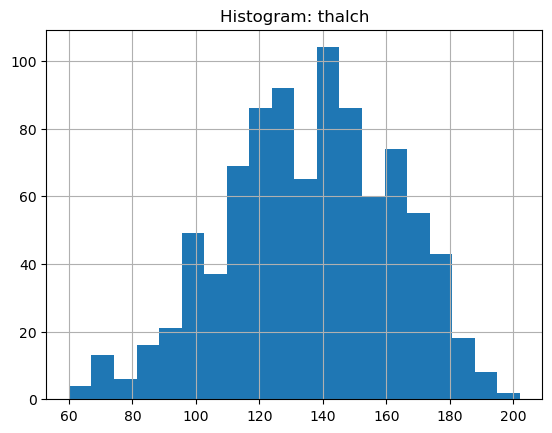

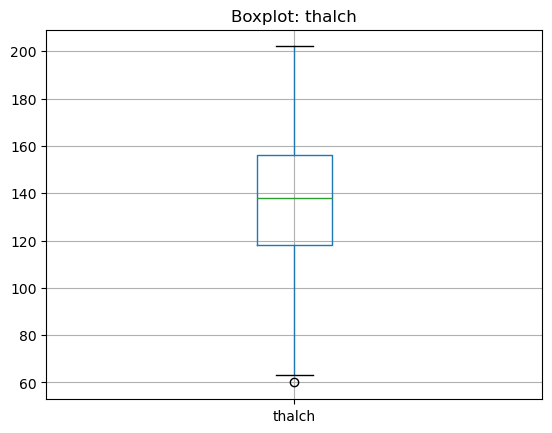

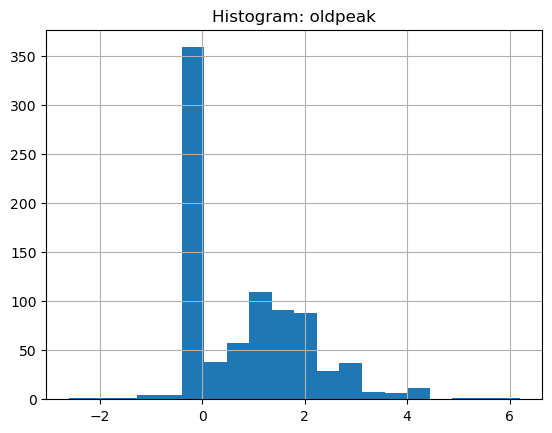

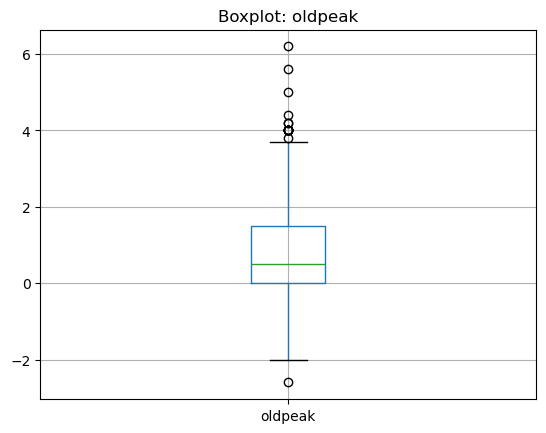

In [62]:
# 4. Histograms and Boxplots for Numerical Columns
import matplotlib.pyplot as plt

num_cols = ['age','trestbps','chol','thalch','oldpeak']
for col in num_cols:
    plt.figure()
    df[col].dropna().hist(bins=20)
    plt.title(f'Histogram: {col}')
    plt.show()

    plt.figure()
    df[[col]].boxplot()
    plt.title(f'Boxplot: {col}')
    plt.show()


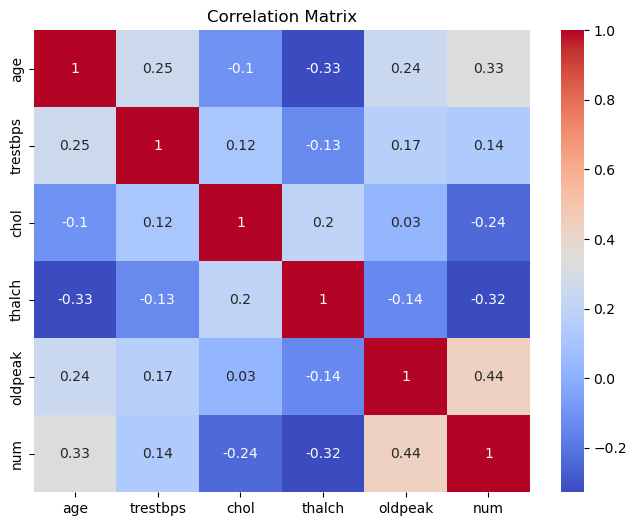

In [63]:
# 5. Correlation Matrix
import seaborn as sns

# Convert to numeric only
corr = df[num_cols + ['num']].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()


In [64]:
# 6. Feature Engineering - Clean binary/boolean fields
df['sex'] = df['sex'].map({'Male': 1, 'Female': 0})
df['fbs'] = df['fbs'].map({'True': 1, 'False': 0})
df['exang'] = df['exang'].map({'True': 1, 'False': 0})

# Replace missing numerical values with median
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

# Fill missing categoricals
cat_enc_cols = ['cp','restecg','slope','thal']
for col in cat_enc_cols:
    df[col] = df[col].astype('category').cat.add_categories(['Unknown']).fillna('Unknown')


In [65]:
# 7. One-hot encode categorical columns
enc_df = pd.get_dummies(df, columns=cat_enc_cols, drop_first=True)

# Remove columns with complete missing after mapping (if any)
for col in ['fbs','exang']:
    if enc_df[col].isnull().all():
        enc_df = enc_df.drop(columns=[col])

# Features and target
X = enc_df.drop(columns=['num'])
y = enc_df['num']        # multi-class (0,1,2,3,4)
y_bin = (y > 0).astype(int)  # binary (0: no disease, 1: disease)


In [66]:
# 8. Train-Test Split & Scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(X, y_bin, test_size=0.2, random_state=42)

num_cols = ['age','trestbps','chol','thalch','oldpeak']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])


In [67]:
# 9. Decision Tree Classification
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)


In [68]:
# 10. Model Evaluation Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(f"Precision: {precision_score(y_test, y_pred):.3f}")
print(f"Recall: {recall_score(y_test, y_pred):.3f}")
print(f"F1 Score: {f1_score(y_test, y_pred):.3f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_pred):.3f}")

print("Classification report:\n", classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.775
Precision: 0.777
Recall: 0.785
F1 Score: 0.781
ROC AUC: 0.774
Classification report:
               precision    recall  f1-score   support

           0       0.77      0.76      0.77        89
           1       0.78      0.78      0.78        93

    accuracy                           0.77       182
   macro avg       0.77      0.77      0.77       182
weighted avg       0.77      0.77      0.77       182

Confusion matrix:
 [[68 21]
 [20 73]]


               feature  importance
3                 chol    0.176998
6   cp_atypical angina    0.151765
0                  age    0.118761
2             trestbps    0.110772
7       cp_non-anginal    0.100919
4               thalch    0.098197
5              oldpeak    0.092415
1                  sex    0.026176
16         thal_normal    0.025357
8    cp_typical angina    0.024091


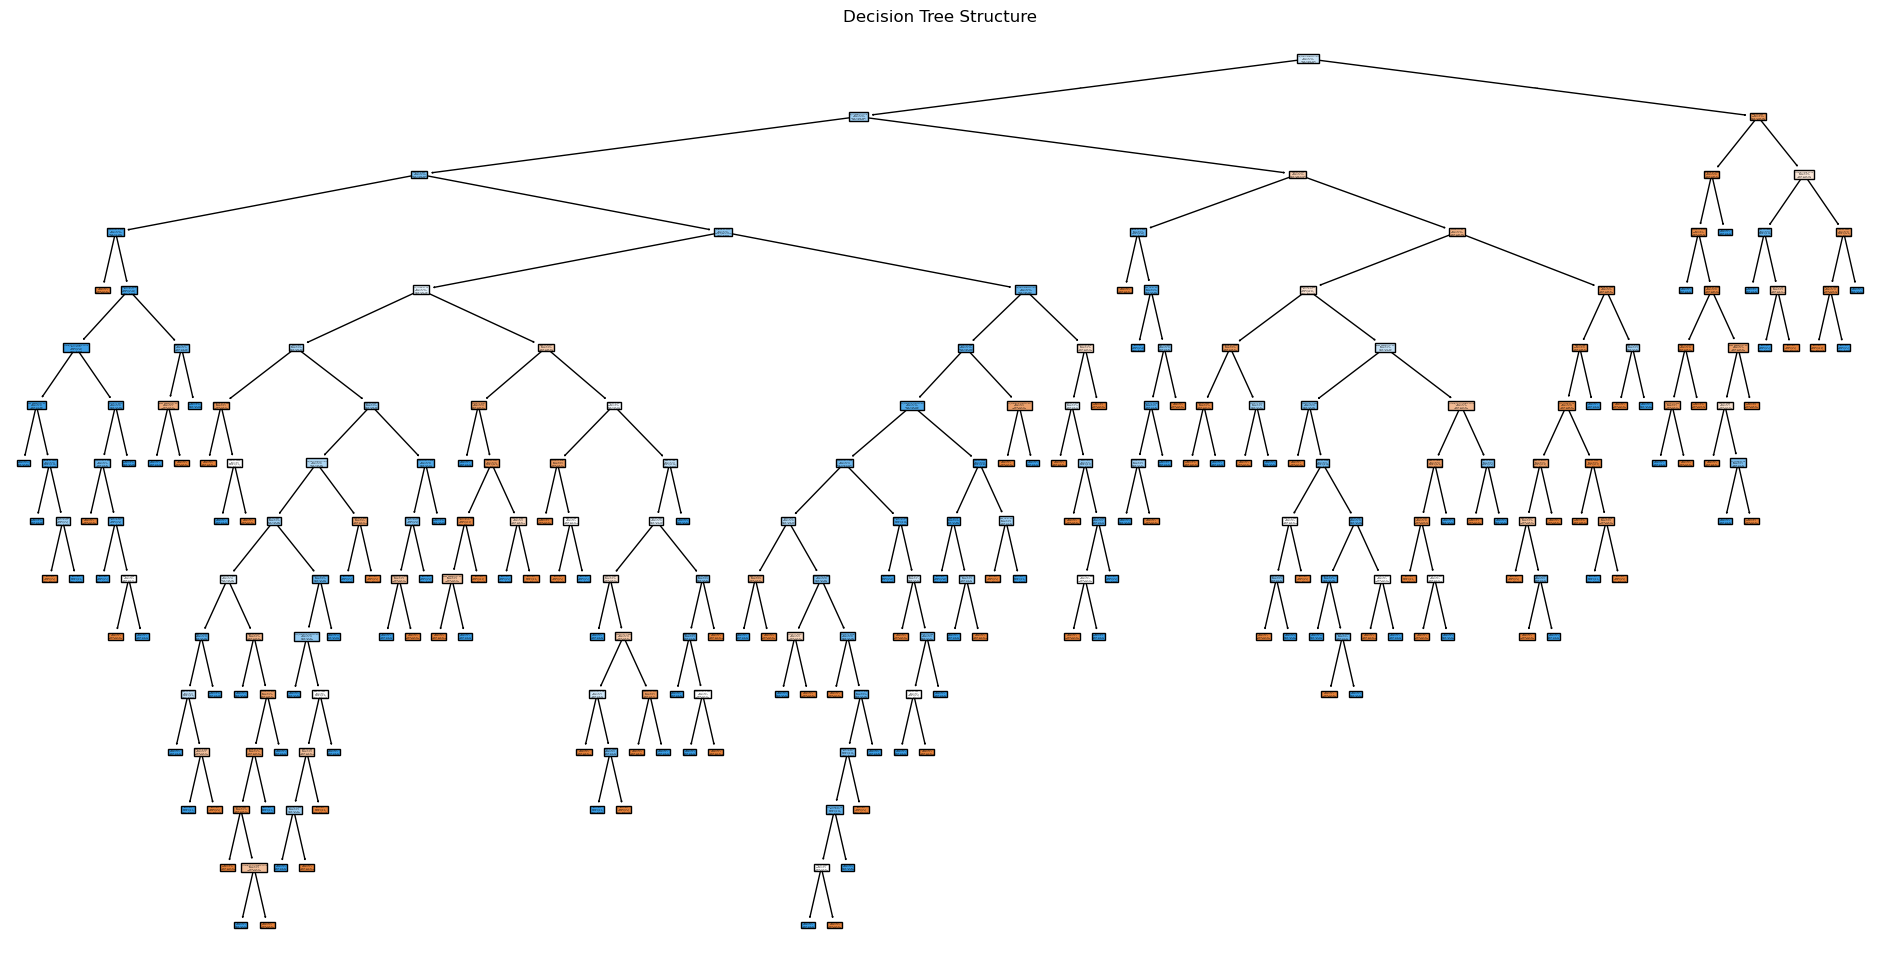

In [69]:
# 11. Feature Importances and Tree Visualization
importances = clf.feature_importances_
features = X_train.columns
imp_df = pd.DataFrame({'feature': features, 'importance': importances}).sort_values('importance', ascending=False)
print(imp_df.head(10))

from sklearn.tree import plot_tree
plt.figure(figsize=(24,12))
plot_tree(clf, feature_names=features, class_names=['NoDisease','Disease'], filled=True)
plt.title('Decision Tree Structure')
plt.show()


In [70]:
# 12. Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3,5,7,9,12,None],
    'min_samples_split': [2,5,10,20],
    'criterion': ['gini', 'entropy']
}
gs = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
gs.fit(X_train, y_train)
print("Best parameters:", gs.best_params_)
print("Best crossval score:", gs.best_score_)


Best parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_split': 20}
Best crossval score: 0.7713745866792632


In [71]:
# 13. Model Evaluation (Best Model)
y_pred_best = gs.predict(X_test)
print("Best Model Test Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_best))


Best Model Test Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

           0       0.81      0.70      0.75        89
           1       0.74      0.84      0.79        93

    accuracy                           0.77       182
   macro avg       0.77      0.77      0.77       182
weighted avg       0.77      0.77      0.77       182

Confusion matrix:
 [[62 27]
 [15 78]]


In [72]:
# 14. Export rules (readable text tree)
from sklearn.tree import export_text
print(export_text(gs.best_estimator_, feature_names=list(features)))


|--- cp_atypical angina <= 0.50
|   |--- cp_non-anginal <= 0.50
|   |   |--- chol <= -1.38
|   |   |   |--- class: 1
|   |   |--- chol >  -1.38
|   |   |   |--- class: 1
|   |--- cp_non-anginal >  0.50
|   |   |--- chol <= -0.71
|   |   |   |--- class: 1
|   |   |--- chol >  -0.71
|   |   |   |--- class: 0
|--- cp_atypical angina >  0.50
|   |--- age <= 0.26
|   |   |--- oldpeak <= 0.02
|   |   |   |--- class: 0
|   |   |--- oldpeak >  0.02
|   |   |   |--- class: 0
|   |--- age >  0.26
|   |   |--- restecg_normal <= 0.50
|   |   |   |--- class: 1
|   |   |--- restecg_normal >  0.50
|   |   |   |--- class: 0



In [ ]:
# 15. Interview Questions Answers
print(\"\"\"Q1. Common hyperparameters of decision tree models:
 - max_depth: controls the maximum depth of the tree (prevents overfitting).
 - min_samples_split: minimum samples required to split a node (limits complexity).
 - min_samples_leaf: minimum samples required at a leaf node.
 - criterion: split quality function (gini, entropy).
 - splitter: split strategy (best, random).
 These affect tree complexity, overfitting, and generalization.

Q2. Difference between Label Encoding and One-hot Encoding:
 - Label encoding: assigns each category a unique integer, best for ordinal categories.
 - One-hot encoding: creates binary columns for each category, ideal for nominal (non-ordinal) features.
 - Decision trees prefer one-hot encoding to avoid false ordering in categorical splits.
\"\"\")
